In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

filepath="/Users/aysha/Desktop/AI Internship/spotify_churn_dataset.csv"

df=pd.read_csv(filepath)

df.head(7)

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1
5,6,Female,17,AU,Free,219,35,0.46,Desktop,13,0,0
6,7,Female,39,UK,Premium,289,44,0.38,Desktop,0,1,0


In [2]:
df.shape

(8000, 12)

In [3]:
df.info

<bound method DataFrame.info of       user_id  gender  age country subscription_type  listening_time  \
0           1  Female   54      CA              Free              26   
1           2   Other   33      DE            Family             141   
2           3    Male   38      AU           Premium             199   
3           4  Female   22      CA           Student              36   
4           5   Other   29      US            Family             250   
...       ...     ...  ...     ...               ...             ...   
7995     7996   Other   44      DE           Student             237   
7996     7997    Male   34      AU           Premium              61   
7997     7998  Female   17      US              Free              81   
7998     7999  Female   34      IN           Student             245   
7999     8000   Other   45      AU              Free             210   

      songs_played_per_day  skip_rate device_type  ads_listened_per_week  \
0                       23 

In [4]:
df.duplicated().value_counts()

False    8000
Name: count, dtype: int64

In [5]:
print(df.isnull().sum())

user_id                  0
gender                   0
age                      0
country                  0
subscription_type        0
listening_time           0
songs_played_per_day     0
skip_rate                0
device_type              0
ads_listened_per_week    0
offline_listening        0
is_churned               0
dtype: int64


In [6]:
churned_count=df['is_churned'].value_counts()
print("Count of Churned Users:",churned_count)

Count of Churned Users: is_churned
0    5929
1    2071
Name: count, dtype: int64


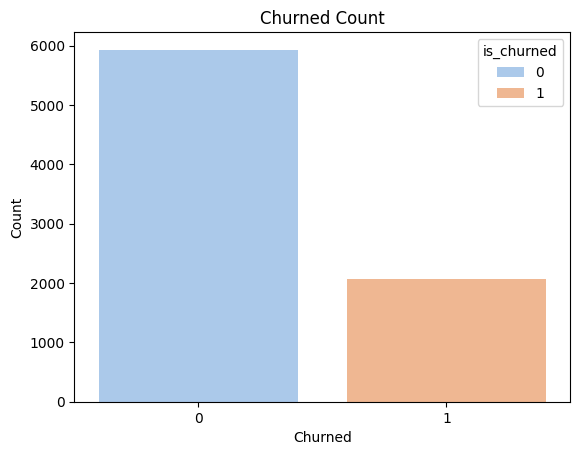

In [9]:
sns.countplot(x='is_churned',data=df,hue='is_churned',palette='pastel')
plt.title('Churned Count')
plt.xlabel('Churned')
plt.ylabel('Count')
plt.show()

In [10]:
gender_count=df['gender'].value_counts()
print("Gender Count=",gender_count)

Gender Count= gender
Male      2691
Female    2659
Other     2650
Name: count, dtype: int64


In [11]:
churned_by_gender=df.groupby(['gender','is_churned']).size()
print("Churned by Gender=",churned_by_gender)

Churned by Gender= gender  is_churned
Female  0             1960
        1              699
Male    0             2013
        1              678
Other   0             1956
        1              694
dtype: int64


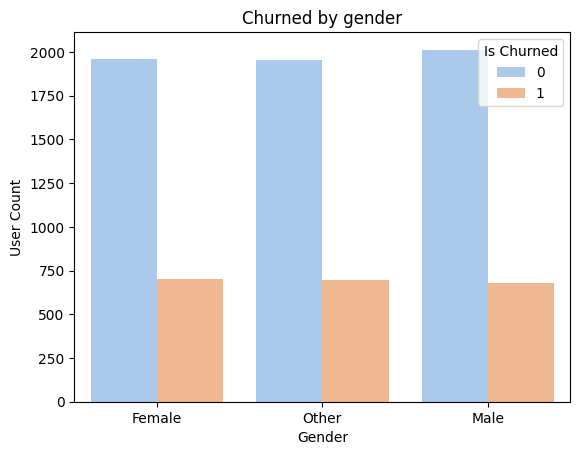

In [16]:
sns.countplot(x='gender',hue='is_churned',data=df,palette='pastel')
plt.title("Churned by gender")
plt.xlabel("Gender")
plt.ylabel("User Count")
plt.legend(title="Is Churned")
plt.show()

In [17]:
subscription_type_count=df['subscription_type'].value_counts()
print("Subscription type Count=",subscription_type_count)

Subscription type Count= subscription_type
Premium    2115
Free       2018
Student    1959
Family     1908
Name: count, dtype: int64


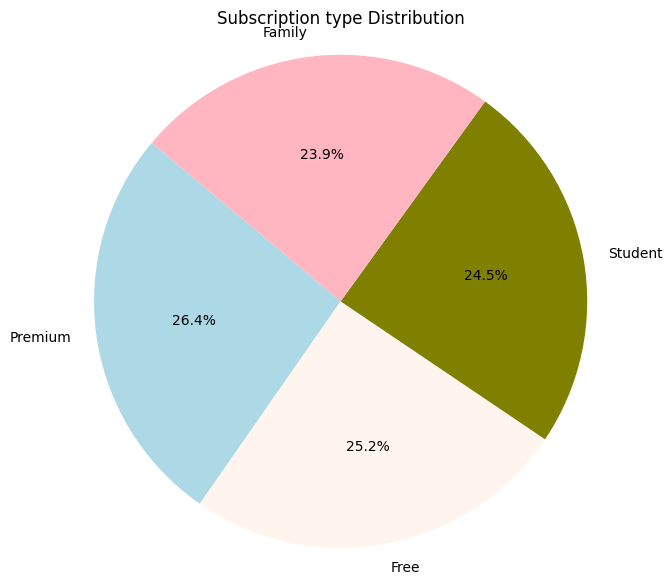

In [19]:
labels=['Premium','Free','Student','Family']
plt.figure(figsize=(7,7))
plt.pie(subscription_type_count,labels=labels,autopct="%1.1f%%",startangle=140,colors=['lightblue','seashell','olive','lightpink'])
plt.title('Subscription type Distribution')
plt.axis('equal')
plt.show()

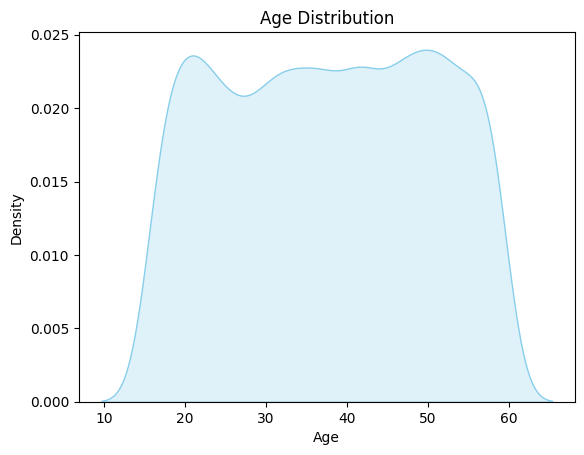

In [21]:
sns.kdeplot(df['age'],fill=True,color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel('Density')
plt.show()

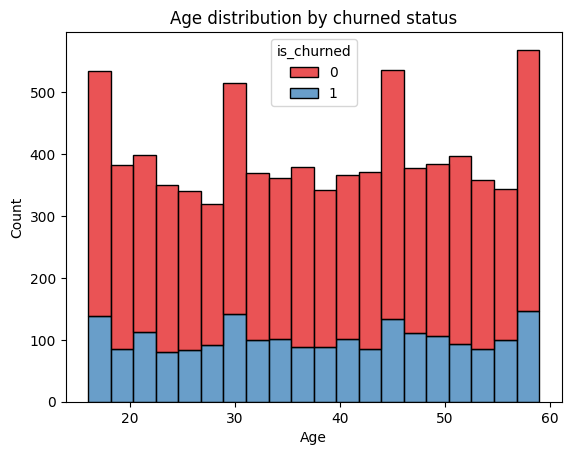

In [22]:
sns.histplot(x='age',hue='is_churned',data=df,multiple='stack',bins=20,palette='Set1')
plt.title("Age distribution by churned status")
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

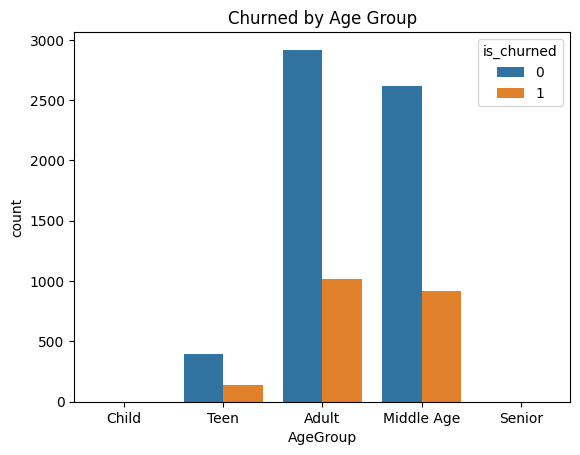

In [23]:
df['AgeGroup']=pd.cut(df['age'],bins=[0,12,18,40,60,100],labels=['Child','Teen','Adult','Middle Age','Senior'])
sns.countplot(x='AgeGroup',hue='is_churned',data=df)
plt.title("Churned by Age Group")
plt.show()